# 6. BO（単一候補・単一目的の例）
- ガウス過程回帰と達成確率に基づき、**1 ステップずつ**候補を選抜するベイズ最適化の参考実装
- 目的変数は設定変数で選択可能

---

## ユーザー設定（ここを編集してください）
**以下のセルで目的変数などを指定してください。1.Preparation.ipynb と同じ設定を使用します。**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd

from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

import lightgbm as lgb

from rdkit import Chem
from rdkit.Chem import Draw

import optuna
import joblib
import os

from IPython.display import display

from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, RBF, ConstantKernel, Matern, DotProduct

np.random.seed(1234)

c:\Users\kawan\miniforge3\envs\chem_win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 学習データとテストデータ読み込み

In [ ]:
# ============================================================
# ユーザー設定: 1.Preparation.ipynb と同じ設定を使用
# ============================================================

# 目的変数の列名（リストで複数指定可能）
TARGET_COLS = ["Emission max (nm)", "Quantum yield"]

# 使用する記述子のタイプ
DESCRIPTOR_TYPE = "rdkit"  # "rdkit" or "mordred_2d" or "mordred_3d" or "fp"

# SMILES列の名前
SMILES_COL = "Chromophore"

# ベイズ最適化で使用する目的変数（単一目的の場合）
BO_TARGET = TARGET_COLS[0]  # 最適化する目的変数を選択

# PTR（Probability of Target Range）の範囲設定
# 目的変数ごとに [min, max] を指定
PTR_RANGES = {
    "Emission max (nm)": [600, 1000],
    "Quantum yield": [0.5, 1.0],
}

# ============================================================
print(f"目的変数: {TARGET_COLS}")
print(f"記述子タイプ: {DESCRIPTOR_TYPE}")
print(f"BO目的変数: {BO_TARGET}")
print(f"PTR範囲: {PTR_RANGES}")

In [2]:
# データ読み込み（設定変数を使用）
dataset_train = pd.read_csv("../data/dataset_train.csv", index_col=0)
target = dataset_train[TARGET_COLS]

if DESCRIPTOR_TYPE == "rdkit":
    des_train = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/rdkit/X_test_rdkit_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_2d":
    des_train = pd.read_csv("outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/mordred_2d/X_test_mordred_2d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "mordred_3d":
    des_train = pd.read_csv("outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/mordred_3d/X_test_mordred_3d_processed.csv", index_col=0)
elif DESCRIPTOR_TYPE == "fp":
    des_train = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)
    des_test = pd.read_csv("outputs/descriptors/fp/X_test_fp.csv", index_col=0)
else:
    raise ValueError(f"未知の DESCRIPTOR_TYPE: {DESCRIPTOR_TYPE}")

# 目的変数と記述子を結合
dataset = target.join(des_train, how="inner")

# テストデータ
x_prediction = des_test.copy()

print(f"dataset: {dataset.shape}")
print(f"x_prediction: {x_prediction.shape}")

dataset: (13132, 208)
x_prediction: (7104, 206)


In [3]:
# データを2000個程度に絞る（GPR は計算量が O(n^3) 級のため件数を制限）
MAX_SAMPLES = 2000
RANDOM_STATE = 1234

if len(dataset) > MAX_SAMPLES:
    dataset = dataset.sample(n=MAX_SAMPLES, random_state=RANDOM_STATE)
    print(f"dataset を {MAX_SAMPLES} 件に間引き: {dataset.shape}")
else:
    print(f"件数 ≤ {MAX_SAMPLES} のためそのまま利用: {dataset.shape}")

dataset を 2000 件に間引き: (2000, 208)


## Gaussian Process Regressor（GPR）
- 目的変数をEmission max (nm)にした場合、PTRの範囲は[600, 1000]
- 目的変数をQuantum yieldにした場合、PTRの範囲は[0.5, 1.0]
- 両方ともPIにしても良い（値が大きいほど望ましいので）

In [4]:
# 目的変数の選択
target = 'Quantum yield'  # 'Emission max (nm)' or 'Quantum yield'

y = dataset[target]  # 目的変数
x = dataset.drop(columns=['Emission max (nm)', 'Quantum yield'])  # 説明変数（残り全部）

In [5]:
# 標準偏差が 0 の特徴量の削除
deleting_variables = x.columns[x.std() == 0]
x = x.drop(deleting_variables, axis=1)
x_prediction = x_prediction.drop(deleting_variables, axis=1)
cumulative_variance = np.zeros(x_prediction.shape[0]) # MI で必要な "ばらつき" を 0 で初期化

x.shape, x_prediction.shape

((2000, 200), (7104, 200))

In [6]:
# カーネル 11 種類
kernels = [ConstantKernel() * DotProduct() + WhiteKernel(),
           ConstantKernel() * RBF() + WhiteKernel(),
           ConstantKernel() * RBF() + WhiteKernel() + ConstantKernel() * DotProduct(),
           ConstantKernel() * RBF(np.ones(x.shape[1])) + WhiteKernel(),
           ConstantKernel() * RBF(np.ones(x.shape[1])) + WhiteKernel() + ConstantKernel() * DotProduct(),
           ConstantKernel() * Matern(nu=1.5) + WhiteKernel(),
           ConstantKernel() * Matern(nu=1.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
           ConstantKernel() * Matern(nu=0.5) + WhiteKernel(),
           ConstantKernel() * Matern(nu=0.5) + WhiteKernel() + ConstantKernel() * DotProduct(),
           ConstantKernel() * Matern(nu=2.5) + WhiteKernel(),
           ConstantKernel() * Matern(nu=2.5) + WhiteKernel() + ConstantKernel() * DotProduct()]

# GPR のハイパーパラメータ
number_of_selecting_samples = 30  # 選択するサンプル数
regression_method = 'gpr_one_kernel'  # gpr_one_kernel', 'gpr_kernels'
acquisition_function = 'PTR'  # 'PTR', 'PI', 'EI', 'MI'

fold_number = 5  # クロスバリデーションの fold 数
kernel_number = 7  # 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10

# PTR
if target == 'Emission max (nm)':
    target_range = [600, 1000]  
else:
    target_range = [0.5, 1.0]

relaxation = 0.01  # EI, PI
delta = 10 ** -6  # MI

print(target_range)

[0.5, 1.0]


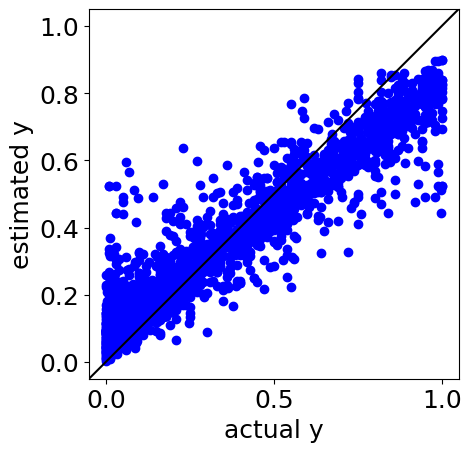

r^2 for training data : 0.8511053673006392
RMSE for training data : 0.11883679776139555
MAE for training data : 0.08993172087946744


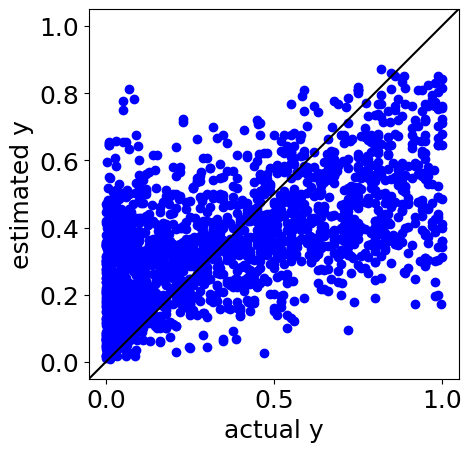

r^2 in cross-validation : 0.3619414042173419
RMSE in cross-validation : 0.24600373508981802
MAE in cross-validation : 0.19481575243526542
sample number : 1 / 30
sample number : 2 / 30
sample number : 3 / 30
sample number : 4 / 30
sample number : 5 / 30
sample number : 6 / 30
sample number : 7 / 30
sample number : 8 / 30
sample number : 9 / 30
sample number : 10 / 30
sample number : 11 / 30
sample number : 12 / 30
sample number : 13 / 30
sample number : 14 / 30
sample number : 15 / 30
sample number : 16 / 30
sample number : 17 / 30
sample number : 18 / 30
sample number : 19 / 30
sample number : 20 / 30
sample number : 21 / 30
sample number : 22 / 30
sample number : 23 / 30
sample number : 24 / 30
sample number : 25 / 30
sample number : 26 / 30
sample number : 27 / 30
sample number : 28 / 30
sample number : 29 / 30
sample number : 30 / 30


In [7]:
# Bayesian optimization
save_dir = "outputs/result/bo"  # 保存先を指定
os.makedirs(save_dir, exist_ok=True)
target_label = target.replace(" ", "_").replace("(", "").replace(")", "")

# 次のサンプル（記述子 + 各ラウンドの y 予測・標準偏差・獲得関数）
next_samples = pd.DataFrame(
    columns=list(x_prediction.columns)
    + ["y_prediction", "y_std", "acquisition_function"]
)

for sample_number in range(number_of_selecting_samples):
    # ===== 1) 学習データ・候補データのオートスケーリング =====
    # 毎ラウンドで、現時点の x, y を基準にスケーリングし直す
    autoscaled_y = (y - y.mean()) / y.std()
    autoscaled_x = (x - x.mean()) / x.std()
    autoscaled_x_prediction = (x_prediction - x.mean()) / x.std()
    
    # ===== 2) GPR モデル構築（単一カーネル or CVでカーネル選択） =====
    if regression_method == 'gpr_one_kernel':
        selected_kernel = kernels[kernel_number]
        model = GaussianProcessRegressor(alpha=0, kernel=selected_kernel)
    elif regression_method == 'gpr_kernels':
        # クロスバリデーションで候補カーネルを比較し、r2 が最大のものを採用
        cross_validation = KFold(n_splits=fold_number, random_state=9, shuffle=True) # クロスバリデーションの分割の設定
        r2cvs = [] # 空の list。カーネル関数ごとに、クロスバリデーション後の r2 を入れていく
        for index, kernel in enumerate(kernels):
            print(index + 1, '/', len(kernels))
            model = GaussianProcessRegressor(alpha=0, kernel=kernel)
            # cross_val_predict は各サンプルに対する out-of-fold 予測を返す
            # （最初/最後の fold の予測だけを使うのではなく、全 fold 分を結合した1本の予測ベクトル）
            estimated_y_in_cv = np.ndarray.flatten(cross_val_predict(model, autoscaled_x, autoscaled_y, cv=cross_validation))
            estimated_y_in_cv = estimated_y_in_cv * y.std(ddof=1) + y.mean()
            r2cvs.append(r2_score(y, estimated_y_in_cv))
        optimal_kernel_number = np.where(r2cvs == np.max(r2cvs))[0][0]  # クロスバリデーション後の r2 が最も大きいカーネル関数の番号
        optimal_kernel = kernels[optimal_kernel_number]  # クロスバリデーション後の r2 が最も大きいカーネル関数
        print('クロスバリデーションで選択されたカーネル関数の番号 :', optimal_kernel_number)
        print('クロスバリデーションで選択されたカーネル関数 :', optimal_kernel)
        
        # モデル構築
        model = GaussianProcessRegressor(alpha=0, kernel=optimal_kernel) # GPR モデルの宣言
    
    # ===== 3) モデル学習 =====
    model.fit(autoscaled_x, autoscaled_y)  
    
    # 初回ラウンドのみ、モデル診断（yyplot・指標・詳細csv）を保存
    if sample_number == 0:
        # 3-1) トレーニングデータの推定
        autoscaled_estimated_y, autoscaled_estimated_y_std = model.predict(autoscaled_x, return_std=True)  # y の推定
        estimated_y = autoscaled_estimated_y * y.std() + y.mean()  # スケールをもとに戻す
        estimated_y_std = autoscaled_estimated_y_std * y.std()  # スケールをもとに戻す
        estimated_y = pd.DataFrame(estimated_y, index=x.index, columns=['estimated_y'])
        estimated_y_std = pd.DataFrame(estimated_y_std, index=x.index, columns=['std_of_estimated_y'])
        
        # トレーニングデータの実測値 vs. 推定値のプロット
        plt.rcParams['font.size'] = 18
        plt.scatter(y, estimated_y.iloc[:, 0], c='blue')  # 実測値 vs. 推定値プロット
        y_max = max(y.max(), estimated_y.iloc[:, 0].max())  # 実測値の最大値と、推定値の最大値の中で、より大きい値を取得
        y_min = min(y.min(), estimated_y.iloc[:, 0].min())  # 実測値の最小値と、推定値の最小値の中で、より小さい値を取得
        plt.plot([y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)],
                 [y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)], 'k-')  # 取得した最小値-5%から最大値+5%まで、対角線を作成
        plt.ylim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  # y 軸の範囲の設定
        plt.xlim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  # x 軸の範囲の設定
        plt.xlabel('actual y')  # x 軸の名前
        plt.ylabel('estimated y')  # y 軸の名前
        plt.gca().set_aspect('equal', adjustable='box')  # 図の形を正方形に
        plt.show()  # 以上の設定で描画
        
        # トレーニングデータのr2, RMSE, MAE
        print('r^2 for training data :', r2_score(y, estimated_y))
        rmse_train = np.sqrt(mean_squared_error(y, estimated_y))
        print('RMSE for training data :', rmse_train)
        print('MAE for training data :', mean_absolute_error(y, estimated_y))
        
        # トレーニングデータの結果の保存
        y_for_save = pd.DataFrame(y)
        y_for_save.columns = ['actual_y']
        y_error_train = y_for_save.iloc[:, 0] - estimated_y.iloc[:, 0]
        y_error_train = pd.DataFrame(y_error_train)
        y_error_train.columns = ['error_of_y(actual_y-estimated_y)']
        results_train = pd.concat([y_for_save, estimated_y, y_error_train, estimated_y_std], axis=1) # 結合
        results_train.to_csv(f"{save_dir}/estimated_y_in_detail_{target_label}_{regression_method}.csv")  # 推定値を保存
        
        # 3-2) クロスバリデーションによる y 推定
        cross_validation = KFold(n_splits=fold_number, random_state=9, shuffle=True) # 例: fold_number=10 なら 10-fold CV
        # ここでの予測は「各サンプルがそのサンプルを学習に使っていない fold モデルで予測された値（OOF）」
        # したがって yyplot は「最初のfoldだけ」「最後のfoldだけ」ではなく、全サンプル分の OOF 予測を描画
        autoscaled_estimated_y_in_cv = cross_val_predict(model, autoscaled_x, autoscaled_y, cv=cross_validation)  # y の推定
        estimated_y_in_cv = autoscaled_estimated_y_in_cv * y.std() + y.mean()  # スケールをもとに戻す
        estimated_y_in_cv = pd.DataFrame(estimated_y_in_cv, index=x.index, columns=['estimated_y'])
        
        # クロスバリデーションにおける実測値 vs. 推定値のプロット
        plt.rcParams['font.size'] = 18
        plt.scatter(y, estimated_y_in_cv.iloc[:, 0], c='blue')  # 実測値 vs. 推定値プロット
        y_max = max(y.max(), estimated_y_in_cv.iloc[:, 0].max())  # 実測値の最大値と、推定値の最大値の中で、より大きい値を取得
        y_min = min(y.min(), estimated_y_in_cv.iloc[:, 0].min())  # 実測値の最小値と、推定値の最小値の中で、より小さい値を取得
        plt.plot([y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)],
                 [y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min)], 'k-')  # 取得した最小値-5%から最大値+5%まで、対角線を作成
        plt.ylim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  # y 軸の範囲の設定
        plt.xlim(y_min - 0.05 * (y_max - y_min), y_max + 0.05 * (y_max - y_min))  # x 軸の範囲の設定
        plt.xlabel('actual y')  # x 軸の名前
        plt.ylabel('estimated y')  # y 軸の名前
        plt.gca().set_aspect('equal', adjustable='box')  # 図の形を正方形に
        plt.show()  # 以上の設定で描画
        
        # クロスバリデーションにおけるr2, RMSE, MAE
        print('r^2 in cross-validation :', r2_score(y, estimated_y_in_cv))
        rmse_cv = np.sqrt(mean_squared_error(y, estimated_y_in_cv))
        print('RMSE in cross-validation :', rmse_cv)
        print('MAE in cross-validation :', mean_absolute_error(y, estimated_y_in_cv))
        
        # クロスバリデーションの結果の保存
        y_error_in_cv = y_for_save.iloc[:, 0] - estimated_y_in_cv.iloc[:, 0]
        y_error_in_cv = pd.DataFrame(y_error_in_cv)
        y_error_in_cv.columns = ['error_of_y(actual_y-estimated_y)']
        results_in_cv = pd.concat([y_for_save, estimated_y_in_cv, y_error_in_cv], axis=1) # 結合
        results_in_cv.to_csv(f"{save_dir}/estimated_y_in_cv_in_detail_{target_label}_{regression_method}.csv")  # 推定値を保存
    
    # ===== 4) 候補点 x_prediction （テストデータ）に対する予測 =====
    estimated_y_prediction, estimated_y_prediction_std = model.predict(autoscaled_x_prediction, return_std=True)
    estimated_y_prediction = estimated_y_prediction * y.std() + y.mean()
    estimated_y_prediction_std = estimated_y_prediction_std * y.std()
    
    # ===== 5) 獲得関数の計算（MI / EI / PI / PTR） =====
    if acquisition_function == 'MI':
        acquisition_function_prediction = estimated_y_prediction + np.log(2 / delta) ** 0.5 * (
                (estimated_y_prediction_std ** 2 + cumulative_variance) ** 0.5 - cumulative_variance ** 0.5)
        cumulative_variance = cumulative_variance + estimated_y_prediction_std ** 2
    elif acquisition_function == 'EI':
        acquisition_function_prediction = (estimated_y_prediction - max(y) - relaxation * y.std()) * \
                                           norm.cdf((estimated_y_prediction - max(y) - relaxation * y.std()) /
                                                     estimated_y_prediction_std) + \
                                           estimated_y_prediction_std * \
                                           norm.pdf((estimated_y_prediction - max(y) - relaxation * y.std()) /
                                                     estimated_y_prediction_std)
    elif acquisition_function == 'PI':
        acquisition_function_prediction = norm.cdf(
                (estimated_y_prediction - max(y) - relaxation * y.std()) / estimated_y_prediction_std)
    elif acquisition_function == 'PTR':
        acquisition_function_prediction = norm.cdf(target_range[1],
                                                   loc=estimated_y_prediction,
                                                   scale=estimated_y_prediction_std
                                                   ) - norm.cdf(target_range[0],
                                                                loc=estimated_y_prediction,
                                                                scale=estimated_y_prediction_std)
    acquisition_function_prediction[estimated_y_prediction_std <= 0] = 0
    
    # ===== 6) 予測結果・獲得関数の DataFrame 化と保存 =====
    estimated_y_prediction = pd.DataFrame(estimated_y_prediction, x_prediction.index, columns=['estimated_y'])
    estimated_y_prediction_std = pd.DataFrame(estimated_y_prediction_std, x_prediction.index, columns=['std_of_estimated_y'])
    acquisition_function_prediction = pd.DataFrame(acquisition_function_prediction, index=x_prediction.index, columns=['acquisition_function'])
    if sample_number == 0:
        estimated_y_prediction.to_csv(f"{save_dir}/estimated_y_prediction_{target_label}_{regression_method}.csv")  # テストデータの予測結果を保存
        estimated_y_prediction_std.to_csv(f"{save_dir}/estimated_y_prediction_{target_label}_{regression_method}_std.csv")  # テストデータの予測値の標準偏差を保存
        acquisition_function_prediction.to_csv(f"{save_dir}/acquisition_function_prediction_{target_label}_{regression_method}_{acquisition_function}.csv")  # 獲得関数を保存

    # ===== 7) 次に実験するサンプルを選択（獲得関数最大） =====
    # 記述子と予測情報を同一行に保持して、履歴 next_samples に追加
    # 1列 DataFrame の idxmax() は Series を返すため、スカラーTagは Series 側で取得
    selected_idx = acquisition_function_prediction.iloc[:, 0].idxmax()
    new_row = x_prediction.loc[[selected_idx]].copy()
    new_row["y_prediction"] = float(
        estimated_y_prediction.loc[selected_idx, "estimated_y"]
    )
    new_row["y_std"] = float(
        estimated_y_prediction_std.loc[selected_idx, "std_of_estimated_y"]
    )
    new_row["acquisition_function"] = float(
        acquisition_function_prediction.loc[selected_idx, "acquisition_function"]
    )
    next_samples = pd.concat([next_samples, new_row], axis=0)

    # ===== 8) 学習データ・候補集合を更新し、次ラウンドへ =====
    # 選ばれた点を x/y に取り込み、候補集合 x_prediction からは削除
    x = pd.concat([x, x_prediction.loc[[selected_idx]]], axis=0)
    y = pd.concat(
        [y, estimated_y_prediction.loc[[selected_idx], "estimated_y"]], axis=0
    )
    x_prediction = x_prediction.drop(selected_idx, axis=0)
    cumulative_variance = np.delete(
        cumulative_variance,
        np.where(acquisition_function_prediction.index == selected_idx)[0][0],
    )
    print('sample number : {0} / {1}'.format(sample_number + 1, number_of_selecting_samples))

## 結果確認

In [8]:
next_samples

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,y_prediction,y_std,acquisition_function
3791,4.683409,4.683409,1.073568,1.073568,0.686114,10.777778,254.358,240.246,254.087769,90,...,0,0,1,0,0,0,0,0.694009,0.185455,0.802771
3796,4.683409,4.683409,1.073568,1.073568,0.686114,10.777778,254.358,240.246,254.087769,90,...,0,0,1,0,0,0,0,0.694264,0.181747,0.811173
3801,4.683409,4.683409,1.073568,1.073568,0.686114,10.777778,254.358,240.246,254.087769,90,...,0,0,1,0,0,0,0,0.694487,0.179157,0.817093
8426,9.015188,9.015188,0.626265,0.626265,0.181829,10.277778,452.516,436.388,452.131349,162,...,0,0,0,0,0,0,0,0.700512,0.195432,0.784845
8427,9.015188,9.015188,0.626265,0.626265,0.181829,10.277778,452.516,436.388,452.131349,162,...,0,0,0,0,0,0,0,0.700575,0.187531,0.802421
8428,9.015188,9.015188,0.626265,0.626265,0.181829,10.277778,452.516,436.388,452.131349,162,...,0,0,0,0,0,0,0,0.700629,0.182863,0.812911
8430,9.015188,9.015188,0.626265,0.626265,0.181829,10.277778,452.516,436.388,452.131349,162,...,0,0,0,0,0,0,0,0.700674,0.179752,0.819938
8431,9.015188,9.015188,0.626265,0.626265,0.181829,10.277778,452.516,436.388,452.131349,162,...,0,0,0,0,0,0,0,0.700714,0.177512,0.825014
8432,9.015188,9.015188,0.626265,0.626265,0.181829,10.277778,452.516,436.388,452.131349,162,...,0,0,0,0,0,0,0,0.700748,0.175807,0.828884
7889,11.040648,11.040648,0.351852,-0.37287,0.421067,14.333333,162.148,156.1,162.042927,60,...,0,0,0,0,0,0,0,0.696091,0.19553,0.78198


In [9]:
# next_samplesのy予測値、yのstd、獲得関数の値をまとめて、pd.DataFrameにする
next_samples_df = next_samples[
    ["y_prediction", "y_std", "acquisition_function"]
]

next_samples_df

,y_prediction,y_std,acquisition_function
3791,0.694009,0.185455,0.802771
3796,0.694264,0.181747,0.811173
3801,0.694487,0.179157,0.817093
8426,0.700512,0.195432,0.784845
8427,0.700575,0.187531,0.802421
8428,0.700629,0.182863,0.812911
8430,0.700674,0.179752,0.819938
8431,0.700714,0.177512,0.825014
8432,0.700748,0.175807,0.828884
7889,0.696091,0.19553,0.78198


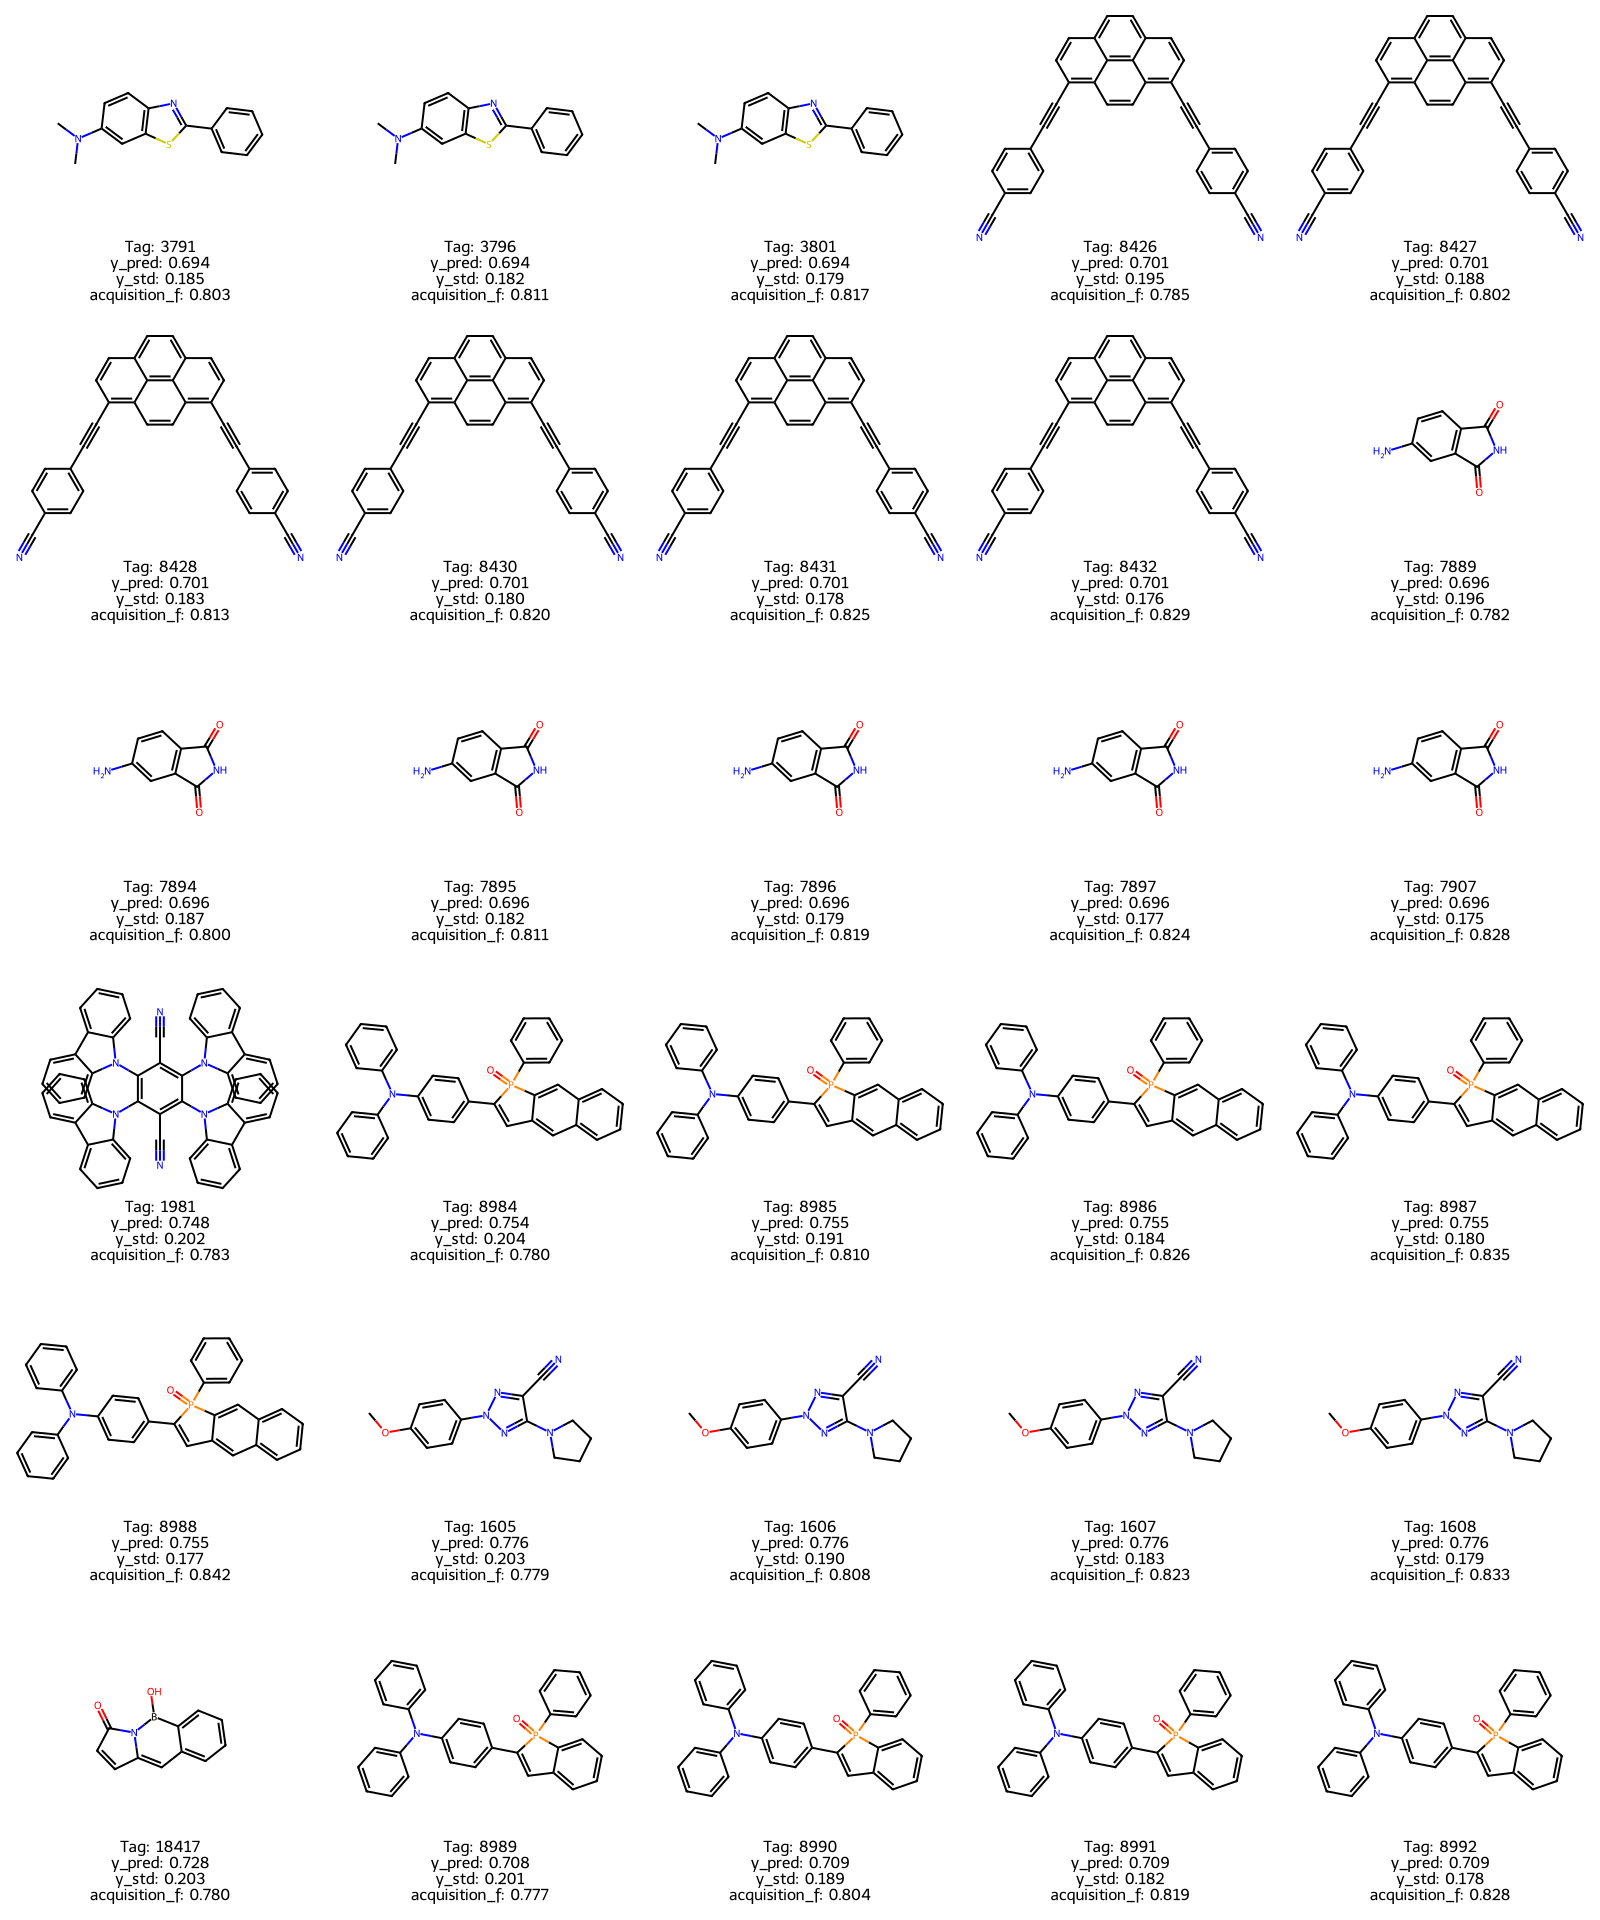

In [10]:
# 選抜候補の化学構造を一覧し、数値との対応を直感的に把握する。

tags = next_samples.index.tolist()

chromophore = pd.concat(
    [
        dataset_train["Chromophore"],
        pd.read_csv("../data/dataset_test.csv", index_col=0)["Chromophore"],
    ]
)
chromophore = chromophore[~chromophore.index.duplicated(keep="first")]
smiles = chromophore.loc[tags]
mols = [Chem.MolFromSmiles(str(s)) for s in smiles]

pred_cols = ["y_prediction", "y_std", "acquisition_function"]
legend_labels = {
    "y_prediction": "y_pred",
    "y_std": "y_std",
    "acquisition_function": "acquisition_f",
}
legends = []
for tag in tags:
    row = next_samples.loc[tag, pred_cols]
    values = [f"{legend_labels[col]}: {row[col]:.3f}" for col in pred_cols]
    legends.append(f"Tag: {tag}\n" + "\n".join(values))

options = Draw.MolDrawOptions()
options.legendFontSize = 32
options.legendFraction = 0.22

display(
    Draw.MolsToGridImage(
        mols,
        molsPerRow=5,
        subImgSize=(320, 320),
        legends=legends,
        drawOptions=options,
        useSVG=True,
    )
)

In [12]:
# 結果を保存（目的変数・回帰手法をファイル名に含める）
os.makedirs(save_dir, exist_ok=True)
save_path = f"{save_dir}/next_samples_bo_multi_samples_{target_label}_{regression_method}.csv"
next_samples_df.to_csv(save_path)
print(f"saved: {save_path}")

saved: outputs/result/bo/next_samples_bo_multi_samples_Quantum_yield_gpr_one_kernel.csv
